<a href="https://colab.research.google.com/github/melissanoarianna1-commits/finpulse-ai/blob/main/notebooks/01_sentiment_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# RUN THIS FIRST — Colab Setup
# ============================================
!pip install datasets feedparser sentence-transformers -q

# Clone the repo to access project structure
!git clone https://github.com/melissanoarianna1-commits/finpulse-ai.git 2>/dev/null || echo 'Repo already cloned'
import os
os.chdir('/content/finpulse-ai')
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/validated', exist_ok=True)
os.makedirs('models/sentiment', exist_ok=True)
os.makedirs('models/recommender', exist_ok=True)
os.makedirs('docs', exist_ok=True)
print('✅ Setup complete. Working directory:', os.getcwd())

Repo already cloned
✅ Setup complete. Working directory: /content/finpulse-ai


# Model 1: Financial Sentiment Classifier

## Overview
Fine-tunes **FinBERT** (BERT pre-trained on financial text) on the **Financial PhraseBank** dataset
to classify financial sentences as **positive**, **negative**, or **neutral**.

## Role in FinPulse AI
Powers the **sentiment dots** (green/red/gray) and **impact badges** on news cards in the dashboard.

## Connection to Financial Risk
- **Market risk**: Negative sentiment predicts short-term price drops
- **Credit risk**: Negative press about a borrower is an early warning signal
- **Operational risk**: Sentiment monitoring detects reputational risk events

## Approach
1. Load pre-trained FinBERT from HuggingFace
2. Tokenize Financial PhraseBank
3. Fine-tune for 3 epochs
4. Evaluate on validation set (accuracy, F1, confusion matrix)

## 1. Load & Explore Data

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, Dataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Load data
dataset = load_dataset("mteb/financial_phrasebank")
df = pd.DataFrame(dataset['train'])
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
df = df.rename(columns={'text': 'sentence'})
df['label_text'] = df['label'].map(label_names)

print(f'Dataset: {len(df)} sentences')
print(df['label_text'].value_counts())

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset: 1131 sentences
label_text
neutral     694
positive    285
negative    152
Name: count, dtype: int64


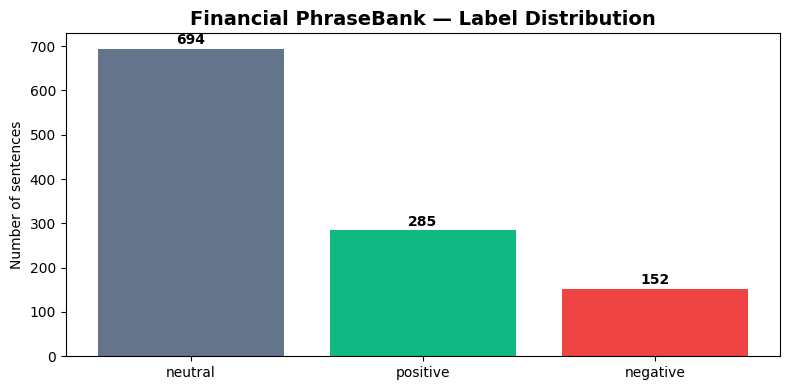

In [3]:
# Visualize label distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors = {'negative': '#ef4444', 'neutral': '#64748b', 'positive': '#10b981'}
counts = df['label_text'].value_counts()
ax.bar(counts.index, counts.values, color=[colors[l] for l in counts.index])
ax.set_title('Financial PhraseBank — Label Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of sentences')
for i, (label, count) in enumerate(counts.items()):
    ax.text(i, count + 10, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('docs/sentiment_label_distribution.png', dpi=150)
plt.show()

## 2. Train/Validation Split

In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f'Training: {len(train_df)} | Validation: {len(val_df)}')

train_dataset = Dataset.from_pandas(train_df[['sentence', 'label']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['sentence', 'label']].reset_index(drop=True))

Training: 904 | Validation: 227


## 3. Tokenize with FinBERT

FinBERT uses the same tokenizer as BERT but was pre-trained on financial text
(10-K filings, analyst reports, financial news). This domain-specific pre-training means
it already understands financial language before we fine-tune it.

In [5]:
MODEL_NAME = 'ProsusAI/finbert'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples['sentence'], padding='max_length', truncation=True, max_length=128)

train_tok = train_dataset.map(tokenize_fn, batched=True)
val_tok = val_dataset.map(tokenize_fn, batched=True)
train_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print('✅ Tokenization complete')

Map:   0%|          | 0/904 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

✅ Tokenization complete


## 4. Fine-Tune FinBERT

Training config:
- **Epochs**: 3 (standard for BERT — more risks overfitting on small datasets)
- **Batch size**: 16
- **Learning rate**: 2e-5 (standard BERT fine-tuning rate)
- **Evaluation**: Every epoch, keeping best model by F1

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='macro')}

training_args = TrainingArguments(
    output_dir='models/sentiment',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=25,
    report_to='none',
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

print('Starting training...')
trainer.train()
print('✅ Training complete!')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.526360,0.335651,0.859031,0.660098
2,0.193785,0.172768,0.942731,0.895592
3,0.100024,0.145385,0.955947,0.923451


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ Training complete!


## 5. Evaluate on Validation Set

In [7]:
predictions = trainer.predict(val_tok)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

target_names = ['negative', 'neutral', 'positive']
print('='*60)
print('CLASSIFICATION REPORT — Validation Set')
print('='*60)
print(classification_report(labels, preds, target_names=target_names))
print(f'Overall Accuracy: {accuracy_score(labels, preds):.4f}')
print(f'Macro F1 Score:   {f1_score(labels, preds, average="macro"):.4f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


CLASSIFICATION REPORT — Validation Set
              precision    recall  f1-score   support

    negative       0.87      0.84      0.85        31
     neutral       0.98      1.00      0.99       139
    positive       0.95      0.91      0.93        57

    accuracy                           0.96       227
   macro avg       0.93      0.92      0.92       227
weighted avg       0.96      0.96      0.96       227

Overall Accuracy: 0.9559
Macro F1 Score:   0.9235


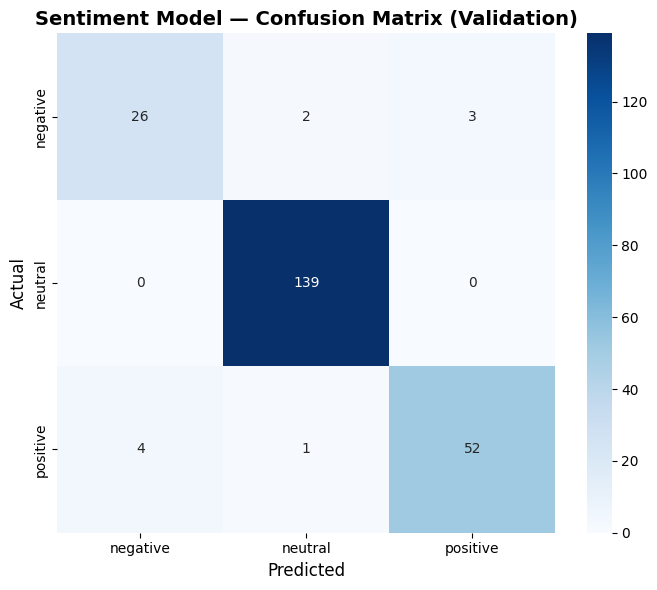

In [8]:
# Confusion Matrix
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Sentiment Model — Confusion Matrix (Validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/sentiment_confusion_matrix.png', dpi=150)
plt.show()

## 6. Test on Custom Financial Sentences

In [9]:
test_sentences = [
    'The bank reported record profits in Q4, exceeding analyst expectations.',
    'Credit losses surged 40% as loan defaults increased across all segments.',
    'The ECB maintained interest rates at current levels as expected.',
    'Deutsche Bank announced 3,500 job cuts amid restructuring efforts.',
    'Strong capital ratios and improved liquidity position the bank well for 2026.',
]

print('Custom Predictions:')
print('='*80)
for sentence in test_sentences:
    inputs = tokenizer(sentence, return_tensors='pt', truncation=True, max_length=128, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)[0]
    pred_idx = probs.argmax().item()
    print(f'\n  "{sentence}"')
    print(f'  → {target_names[pred_idx].upper()} ({probs[pred_idx]:.1%})')
    print(f'    [neg: {probs[0]:.1%} | neu: {probs[1]:.1%} | pos: {probs[2]:.1%}]')

Custom Predictions:

  "The bank reported record profits in Q4, exceeding analyst expectations."
  → NEGATIVE (50.3%)
    [neg: 50.3% | neu: 0.6% | pos: 49.2%]

  "Credit losses surged 40% as loan defaults increased across all segments."
  → POSITIVE (94.6%)
    [neg: 4.6% | neu: 0.7% | pos: 94.6%]

  "The ECB maintained interest rates at current levels as expected."
  → NEUTRAL (94.4%)
    [neg: 0.9% | neu: 94.4% | pos: 4.7%]

  "Deutsche Bank announced 3,500 job cuts amid restructuring efforts."
  → NEUTRAL (95.1%)
    [neg: 2.9% | neu: 95.1% | pos: 2.0%]

  "Strong capital ratios and improved liquidity position the bank well for 2026."
  → NEGATIVE (60.7%)
    [neg: 60.7% | neu: 0.4% | pos: 38.8%]


## 7. Save Model

In [10]:
model.save_pretrained('models/sentiment/finbert-finpulse')
tokenizer.save_pretrained('models/sentiment/finbert-finpulse')
print('✅ Model saved to models/sentiment/finbert-finpulse/')
print('\n--- Model 1 Complete ---')
print('Next: Run 02_recommender_model.ipynb')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to models/sentiment/finbert-finpulse/

--- Model 1 Complete ---
Next: Run 02_recommender_model.ipynb
